# 07-3. 검증과 재검색 루프가 있는 Tavily 뉴스 에이전트

이 실습은 2단계 검색 리포트 그래프에 검증 노드와 재검색 루프를 추가하는 예제이다.

## 학습 목표

1. 검색 결과가 충분한지 검증하는 노드를 만든다.
2. 조건부 Edge로 `리포트작성` 또는 `검색어재작성`으로 분기한다.
3. 검색 결과가 부족하면 검색어를 바꾸어 다시 검색한다.
4. 무한 루프를 막기 위해 최대 검색 횟수를 제한한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

이 단계는 앞선 두 실습을 모두 이해한 뒤 진행하는 확장 실습이다.


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
OPENAI_API_KEY=발급받은_OpenAI_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from const.const import API_KEY, MODEL, TAVILY_API_KEY


OPENAI_API_KEY = API_KEY
TAVILY_API_KEY = TAVILY_API_KEY

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")


환경 변수 로드 완료


In [15]:
# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, temperature=0.2, timeout=600)

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)


In [4]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(f"[{idx}] {title}\nURL: {url}\n내용: {content}")

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


## 1. State 정의

3단계에서는 조건부 분기와 재검색을 위해 State 필드가 늘어난다.

| 필드             | 의미                       |
| ---------------- | -------------------------- |
| `topic`          | 사용자가 입력한 원래 주제  |
| `search_query`   | 현재 검색어                |
| `search_results` | 현재 검색 결과             |
| `is_sufficient`  | 검색 결과가 충분한지 여부  |
| `feedback`       | 검증 결과 또는 재검색 이유 |
| `search_count`   | 검색을 실행한 횟수         |
| `report`         | 최종 리포트                |


In [5]:
class AdvancedNewsState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 현재 Tavily 검색에 사용할 검색어이다.
    search_query: str

    # 현재 검색 결과 목록이다.
    search_results: list[dict]

    # 검색 결과가 리포트 작성에 충분한지 표시한다.
    is_sufficient: bool

    # 검증 결과나 재검색 이유를 저장한다.
    feedback: str

    # 검색이 몇 번 실행되었는지 저장한다.
    search_count: int

    # 최종 리포트이다.
    report: str


## 2. 검색 노드 정의

검색 노드는 현재 `search_query`를 사용한다.  
단, 처음 실행할 때 `search_query`가 비어 있으면 `topic`을 검색어로 사용한다.

재검색 루프가 발생하면 `검색어재작성` 노드가 만든 새 검색어를 사용한다.


In [6]:
def search_node(state: AdvancedNewsState) -> dict:
    """현재 검색어로 Tavily 검색을 수행하는 노드이다."""

    # search_query가 비어 있으면 topic을 검색어로 사용한다.
    query = state.get("search_query") or state["topic"]

    # 검색 횟수를 1 증가시킨다.
    search_count = state.get("search_count", 0) + 1

    print(f"[{search_count}회차 검색] {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


## 3. 검증 노드 정의

검증 노드는 검색 결과가 충분한지 판단한다.

초보자 실습에서는 기준을 단순하게 둔다.

- 검색 결과가 3개 이상이면 충분하다고 본다.
- 최대 검색 횟수에 도달하면 더 이상 재검색하지 않는다.

실무에서는 URL 신뢰도, 날짜, 중복 여부, 원문 길이 등을 추가로 검증할 수 있다.


In [7]:
MAX_SEARCH_COUNT = 2


def validate_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 충분한지 판단하는 노드이다."""

    results = state["search_results"]
    search_count = state["search_count"]

    # 초보자 실습에서는 검색 결과 개수만으로 충분성을 판단한다.
    has_enough_results = len(results) >= 3

    # 무한 재검색을 막기 위해 최대 검색 횟수를 제한한다.
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하다.",
        }

    if reached_limit:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하지 않지만 최대 검색 횟수에 도달해 리포트를 작성한다.",
        }

    return {
        "is_sufficient": False,
        "feedback": "검색 결과가 부족하다. 더 구체적인 검색어가 필요하다.",
    }


## 4. 검색어 재작성 노드 정의

검색 결과가 부족하면 LLM을 사용해 검색어를 다시 작성한다.

이 노드는 `search_query`만 변경한다.  
다음 검색 노드는 변경된 검색어를 사용한다.


In [ ]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            너는 웹 검색어를 개선하는 AI이다.
            사용자의 주제와 피드백을 바탕으로 더 구체적인 한국어 검색어 하나만 작성한다.
            설명 없이 검색어만 출력한다.
            """.strip(),
        ),
        (
            "human",
            """
            원래 주제: {topic}
            현재 검색어: {search_query}
            피드백: {feedback}

            개선된 검색어:
            """.strip(),
        ),
    ]
)

rewrite_chain = rewrite_prompt | llm | StrOutputParser()


def rewrite_query_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 부족할 때 검색어를 다시 작성하는 노드이다."""

    new_query = rewrite_chain.invoke(
        {
            "topic": state["topic"],
            "search_query": state["search_query"],
            "feedback": state["feedback"],
        }
    ).strip()

    print(f"재작성된 검색어: {new_query}")

    return {"search_query": new_query}


## 5. 리포트 작성 노드 정의

리포트 작성 노드는 현재 검색 결과와 검증 피드백을 함께 사용한다.  
검색 결과가 부족한 상태로 최대 검색 횟수에 도달했을 수도 있으므로, 한계도 리포트에 반영한다.


In [9]:
report_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 검색 결과가 부족하면 한계를 명시한다.
5. 한국어로 작성한다.
""".strip(),
        ),
        (
            "human",
            """
주제: {topic}
검색어: {search_query}
검증 피드백: {feedback}

검색 결과:
{search_results}

위 내용을 바탕으로 뉴스 리포트를 작성하라.
""".strip(),
        ),
    ]
)

report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: AdvancedNewsState) -> dict:
    """검색 결과를 바탕으로 최종 리포트를 작성하는 노드이다."""

    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke(
        {
            "topic": state["topic"],
            "search_query": state["search_query"],
            "feedback": state["feedback"],
            "search_results": search_text,
        }
    )

    return {"report": report}


## 6. 라우팅 함수 정의

조건부 Edge는 라우팅 함수의 반환값에 따라 다음 노드를 선택한다.

- `is_sufficient=True`이면 `리포트작성`으로 이동한다.
- `is_sufficient=False`이면 `검색어재작성`으로 이동한다.


In [10]:
def route_after_validation(state: AdvancedNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


## 7. 그래프 구성

조건부 Edge와 루프를 포함한 그래프를 구성한다.

`path_map`을 명시하면 라우팅 함수의 반환값과 실제 이동할 노드의 관계가 분명해진다.  
그래프 시각화도 더 정확하게 표시된다.


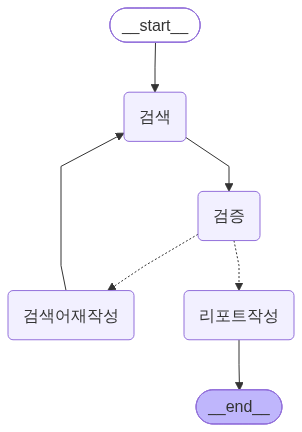

In [11]:
builder = StateGraph(AdvancedNewsState)

builder.add_node("검색", search_node)
builder.add_node("검증", validate_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "검증")

# 검증 결과에 따라 리포트 작성 또는 검색어 재작성으로 분기한다.
builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 검색어를 다시 작성하면 검색 노드로 돌아간다.
builder.add_edge("검색어재작성", "검색")

builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


## 8. 그래프 실행

검색 결과가 충분하면 한 번만 검색하고 리포트를 작성한다.  
검색 결과가 부족하면 검색어를 다시 작성하고 한 번 더 검색한다.


In [12]:
initial_state = {
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "is_sufficient": False,
    "feedback": "",
    "search_count": 0,
    "report": "",
}

result = app.invoke(initial_state)

print("최종 검색어:", result["search_query"])
print("검색 횟수:", result["search_count"])
print("검증 피드백:", result["feedback"])
print("\n[최종 리포트]")
print(result["report"])


[1회차 검색] 인공지능 최신 동향
검색 결과 수: 5
최종 검색어: 인공지능 최신 동향
검색 횟수: 1
검증 피드백: 검색 결과가 충분하다.

[최종 리포트]
**📰 인공지능 최신 동향 브리핑**

---

### **1. 시장 규모 및 성장 전망**
*   **전 세계 AI 시장**: 2023년 기준 **2,146억 달러** 규모이며, 2030년까지 **1조 3,391억 달러**로 연평균 **35.7%** 성장할 전망(ETRI, 가트너 인용) [1].
*   **생성형 AI 시장**: 2026년 **833억 달러** 규모, 연평균 **31.6%** 성장 예상(와인스펙, 세일즈포스 자료 인용) [2].
*   **AI 사이버보안 시장**: 모건스탠리는 2030년까지 글로벌 시장 규모가 약 **1,350억 달러**에 이를 것으로 전망(봇프레스) [3].

---

### **2. 핵심 기술 트렌드: '에이전틱 AI' 및 '에이전틱 엔터프라이즈'로의 전환**
*   **가트너 2025 10대 전략 기술**: **'에이전트 AI(Agentic AI)'**, 'AI 거버넌스 플랫폼' 등을 주요 트렌드로 선정 [1].
*   **2026년 핵심 키워드 '에이전틱 엔터프라이즈'**: AI 시스템이 **반응형→선제적(목표 위임형)**, **범용 LLM→도메인 특화**, **불확실성→측정 가능한 신뢰성**, **사람 중심→사람·에이전트·시스템 혼합** 업무 구조로 임계점을 넘음(와인스펙, 세일즈포스/캐럿글로벌 자료) [2].
*   **AI 에이전트 1위 트렌드**: 가트너, 맥킨지, IBM, 포레스터 등 주요 기관이 2025년 최우선 트렌드로 'AI 에이전트' 꼽음. 단순 자동화 넘어 복잡·다단계 업무 자율 처리 단계로 진입(봇프레스) [3].
*   **추론 비용 획기적 감소**: 2025년 상반기 주요 트렌드로 기존 아이디어의 적용 방식 변화 중 추론 비용 감소가 실용적 진전으로 꼽힘(IBM) [4].

---

### **3. 글로벌 거버넌스 및 안전 규제 동향**

## 9. stream으로 실행 흐름 확인

`stream_mode="updates"`를 사용하면 각 노드가 어떤 값을 반환했는지 단계별로 확인할 수 있다.


In [13]:
for event in app.stream(initial_state, stream_mode="updates"):
    print(f"event.keys() : {event.keys()}")
    print(f"event: {event}")
    print("-" * 80)


[1회차 검색] 인공지능 최신 동향
검색 결과 수: 5
event.keys() : dict_keys(['검색'])
event: {'검색': {'search_query': '인공지능 최신 동향', 'search_results': [{'url': 'https://ettrends.etri.re.kr/ettrends/212/0905212008/0905212008.html', 'title': '인공지능 분야 산업·기술 동향 및 이슈', 'content': '인공지능(AI: Artificial Intelligence) 산업은 생성형 AI의 등장 이후 빠르게 성장하고 있으며, 최근 출시된 각종 AI 서비스는 실생활에 적용되며 그 영역을 확장해 나가고 있다. 전 세계 인공지능 시장 규모는 2023년 기준 2,146억 달러에 달하며, 2030년 1조 3,391억 달러로 연평균 35.7% 성장할 것으로 전망된다. Gartner는 2025년 10대 전략 기술 트렌드에서 “에이전트 AI(Agentic AI)”, “AI 거버넌스 플랫폼(AI Governance Platform)” 등을 주요 트렌드로 꼽았으며, 몇 해 전부터 AI를 주요 기술 트렌드로 다루고 있기도 하다. 또한, 최근 기계학습(Machine Learning)의 기반을 구축한 존 홉필드 프린스턴대학교 교수와 제프리 힌턴 토론토대학교 교수의 노벨 물리학상 수상, 그리고 AI 모델로 단백질 구조를 예측하는 알파폴드(AlphaFold)를 개발한 데미스 허사비스 딥마인드 최고경영자와 존 점퍼 [...] Cow-shed, "Using Artificial Intelligence to Improve Transport in London," May 29, 2024. \n\n Austrailian Government Department of Education, "Australian Framework for Generative AI in Schools," Nov. 17, 2023.\n\n L. Richardson, "안전한 생성형 AI 사

In [16]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))

[1회차 검색] 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기
검색 결과 수: 5

[1] 교육 분야에서 생성형 AI를 활용하는 10가지 주요 사례 | 가이드
https://www.hdwebsoft.com/ko/blog/top-10-use-cases-of-generative-ai-in-education
방대한 데이터 세트를 실시간으로 분석할 수 있는 능력을 갖춘 생성형 AI는 교육에 상당한 이점을 제공합니다. 예를 들어, 교육 기관은 이를 통해 학습 패턴을 효과적으로 파악할 수 있습니다. 또한, 학생 성과를 정확하게 평가하고 다양한 학생 요구에 맞춰 교육 전략을 동적으로 조정할 수 있습니다. 교육에 생성형 AI를 도입하면 운영을 최적화할 뿐만 아니라 혁신적인 교수법을 도입할 수 있습니다. 궁극적으로 AI를 통해 학습은 더욱 흥미롭고 효과적이게 됩니다.

교육 분야의 생성형 AI 시장은 빠르게 성장하고 있습니다. 최근 추산에 따르면 전 세계 교육 AI 시장 규모는 189억 2,400만 달러에 달합니다. 2025년에는 개인 맞춤형 학습 솔루션과 고급 교육 도구에 대한 수요가 증가할 것으로 예상됩니다. 이러한 급증세는 생성형 AI(GenAI)가 교육 제공 및 소비 방식을 재정의하며 보여주는 혁신적인 잠재력을 강조합니다.

## 교육 분야에서 생성형 AI의 이점 [...] GenAI(생성형 AI)는 텍스트, 이미지, 비디오, 심지어 소프트웨어 코드와 같은 콘텐츠를 생성할 수 있는 고급 머신러닝 모델을 의미합니다. 교육 분야에서 이 기술은 기존의 교육 및 학습 과정을 혁신할 수 있는 능력으로 주목받고 있습니다. 특히, 개별 학생의 요구에 맞춘 맞춤형 학습 경험을 개발하고 고품질 교육 자료를 생성하는 데 활용되고 있습니다. 또한, 교육자들이 행정 업무를 더욱 효율적으로 관리할 수 있도록 지원하여 전반적인 생산성과 효율성을 향상시킵니다. [...] ### 오래된 학습 자료 복원

또한, 교육 분야의 생성형 AI는 오래되었거나 손상된 교육 자료에 새로운 생명

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 조건부 Edge는 State 값에 따라 다음 노드를 다르게 선택한다.
2. 검색 결과가 부족하면 검색어를 다시 작성하고 검색 노드로 돌아갈 수 있다.
3. 루프를 사용할 때는 최대 반복 횟수 같은 안전장치가 필요하다.
4. 이 구조는 검색 기반 리포트 생성, 상품 추천, 문서 검토, RAG 품질 개선 등에 응용할 수 있다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. State 정의
from typing_extensions import TypedDict

class AdvancedNewsState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    is_sufficient: bool
    feedback: str
    search_count: int
    report: str


# 3. 검색 노드
def search_node(state: AdvancedNewsState) -> dict:
    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


# 4. 검증 노드
MAX_SEARCH_COUNT = 2

def validate_node(state: AdvancedNewsState) -> dict:
    results = state["search_results"]
    search_count = state["search_count"]

    has_enough_results = len(results) >= 3
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하다.",
        }

    if reached_limit:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하지 않지만 최대 검색 횟수에 도달해 리포트를 작성한다.",
        }

    return {
        "is_sufficient": False,
        "feedback": "검색 결과가 부족하다. 더 구체적인 검색어가 필요하다.",
    }


# 5. 조건부 Edge로 검증 후 분기
def route_after_validation(state: AdvancedNewsState) -> str:
    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)


# 6. 재검색 루프
builder.add_edge("검색어재작성", "검색")
```

- 노드 설명

| 노드         | 역할                                                                 |
| ------------ | -------------------------------------------------------------------- |
| 검색         | 현재 검색어로 Tavily Search API를 호출해 웹 검색을 수행한다.         |
| 검증         | 검색 결과 개수와 최대 검색 횟수를 기준으로 결과가 충분한지 판단한다. |
| 검색어재작성 | 검색 결과가 부족할 때 LLM으로 더 구체적인 검색어를 생성한다.         |
| 리포트작성   | 최종 검색 결과와 검증 피드백을 바탕으로 뉴스 리포트를 작성한다.      |

- State 필드 설명

| State 필드       | 의미                                                |
| ---------------- | --------------------------------------------------- |
| `topic`          | 사용자가 입력한 원래 주제이다.                      |
| `search_query`   | 현재 Tavily 검색에 사용하는 검색어이다.             |
| `search_results` | Tavily에서 반환한 현재 검색 결과 목록이다.          |
| `is_sufficient`  | 검색 결과가 리포트 작성에 충분한지 나타내는 값이다. |
| `feedback`       | 검증 결과 또는 재검색이 필요한 이유이다.            |
| `search_count`   | 검색 노드가 실행된 횟수이다.                        |
| `report`         | LLM이 작성한 최종 뉴스 리포트이다.                  |

이 실습은 LangGraph에서 **외부 API 호출, 조건부 분기, 재검색 루프, LLM 기반 검색어 재작성, LLM 리포트 작성**을 하나의 그래프로 구성하는 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

07-2 실습이 `검색 → 리포트작성`의 단순 파이프라인이었다면, 07-3 실습은 여기에 **검증 노드와 재검색 루프**를 추가한 구조이다.

이 구조에서 가장 중요한 부분은 다음 두 가지이다.

1. `검증` 노드는 State의 `is_sufficient` 값을 결정한다.
2. 조건부 Edge는 `is_sufficient` 값에 따라 `리포트작성`으로 갈지, `검색어재작성`으로 갈지 결정한다.

따라서 07-3 실습의 핵심은 단순히 검색 결과를 리포트로 만드는 것이 아니라, **검색 결과의 품질을 확인하고 부족하면 다시 검색하는 Agentic Workflow**를 구성하는 데 있다.
